In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from textblob import TextBlob
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

print("="*60)
print("TASK 3: SENTIMENT ANALYSIS & CORRELATION")
print("="*60)
print("✅ Libraries imported!")

TASK 3: SENTIMENT ANALYSIS & CORRELATION
✅ Libraries imported!


In [16]:
# Load news data
news_df = pd.read_csv('../data/raw/raw_analyst_ratings.csv')

print(f"📂 Loaded {len(news_df):,} news articles")
print(f"📋 Columns: {news_df.columns.tolist()}")

# Find date and headline columns
date_col = None
headline_col = None

for col in news_df.columns:
    if 'date' in col.lower():
        date_col = col
    elif 'headline' in col.lower() or 'title' in col.lower():
        headline_col = col

print(f"📅 Date column: {date_col}")
print(f"📰 Headline column: {headline_col}")

📂 Loaded 1,407,328 news articles
📋 Columns: ['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']
📅 Date column: date
📰 Headline column: headline


In [17]:
# Clean dates
news_df['parsed_date'] = pd.to_datetime(news_df[date_col], errors='coerce')
news_df = news_df.dropna(subset=['parsed_date'])
news_df['date_only'] = news_df['parsed_date'].dt.date

print(f"📅 Date range: {news_df['parsed_date'].min()} to {news_df['parsed_date'].max()}")
print(f"✅ Cleaned: {len(news_df):,} articles")

📅 Date range: 2011-04-27 21:01:48-04:00 to 2020-06-11 17:12:35-04:00
✅ Cleaned: 55,987 articles


In [18]:
# Load AAPL stock data
aapl = pd.read_csv('../data/raw/AAPL.csv')
aapl['Date'] = pd.to_datetime(aapl['Date'])
aapl = aapl.sort_values('Date')
aapl['daily_return'] = aapl['Close'].pct_change() * 100

print(f"📈 Loaded AAPL: {len(aapl)} days")
print(f"📅 AAPL range: {aapl['Date'].min()} to {aapl['Date'].max()}")
print(aapl[['Date', 'Close', 'daily_return']].head(3))

📈 Loaded AAPL: 3774 days
📅 AAPL range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00
        Date     Close  daily_return
0 2009-01-02  2.721686           NaN
1 2009-01-05  2.836553      4.220416
2 2009-01-06  2.789767     -1.649399


In [19]:
# Sentiment function
def get_sentiment(text):
    try:
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0

# Test the function
test_text = "Apple stock hits all-time high"
print(f"Test: '{test_text}'")
print(f"Sentiment score: {get_sentiment(test_text)}")

Test: 'Apple stock hits all-time high'
Sentiment score: 0.16


In [20]:
# Apply sentiment to headlines (using sample for speed)
sample_size = 30000
news_sample = news_df.head(sample_size).copy()

print(f"📝 Processing {sample_size:,} headlines...")
news_sample['sentiment'] = news_sample[headline_col].apply(get_sentiment)

print(f"\n✅ Complete!")
print(f"📊 Mean sentiment: {news_sample['sentiment'].mean():.4f}")
print(f"😊 Positive headlines: {(news_sample['sentiment'] > 0).sum():,}")
print(f"😞 Negative headlines: {(news_sample['sentiment'] < 0).sum():,}")
print(f"😐 Neutral headlines: {(news_sample['sentiment'] == 0).sum():,}")

📝 Processing 30,000 headlines...

✅ Complete!
📊 Mean sentiment: 0.0406
😊 Positive headlines: 7,727
😞 Negative headlines: 2,485
😐 Neutral headlines: 19,788


In [21]:
# Daily average sentiment
daily_sentiment = news_sample.groupby('date_only')['sentiment'].mean().reset_index()
daily_sentiment.columns = ['date', 'avg_sentiment']
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])

print(f"📅 {len(daily_sentiment)} days with sentiment data")
print(daily_sentiment.head(5))

📅 2329 days with sentiment data
        date  avg_sentiment
0 2011-04-27       0.000000
1 2011-04-28       0.068182
2 2011-04-29       0.166667
3 2011-05-01       0.000000
4 2011-05-02       0.000000


In [22]:
# Merge with stock returns
merged = pd.merge(
    daily_sentiment,
    aapl[['Date', 'daily_return']],
    left_on='date',
    right_on='Date',
    how='inner'
)

print(f"🔗 Merged: {len(merged)} matching days")
print(merged[['date', 'avg_sentiment', 'daily_return']].head(5))

🔗 Merged: 2120 matching days
        date  avg_sentiment  daily_return
0 2011-04-27       0.000000     -0.077042
1 2011-04-28       0.068182     -0.971032
2 2011-04-29       0.166667      0.974822
3 2011-05-02       0.000000     -1.099651
4 2011-05-03       0.000000      0.554465


In [23]:
# Calculate correlation
correlation = merged['avg_sentiment'].corr(merged['daily_return'])

print("="*50)
print(f"📊 PEARSON CORRELATION: {correlation:.4f}")
print("="*50)

if correlation > 0.2:
    print("💡 POSITIVE correlation - Good news with positive returns")
elif correlation < -0.2:
    print("💡 NEGATIVE correlation - Good news with negative returns")
else:
    print("💡 WEAK correlation - News and returns not strongly linked")

📊 PEARSON CORRELATION: 0.0038
💡 WEAK correlation - News and returns not strongly linked


In [24]:
# Classify sentiment
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

merged['sentiment_class'] = merged['avg_sentiment'].apply(classify_sentiment)
returns_by_class = merged.groupby('sentiment_class')['daily_return'].mean()

print("📊 AVERAGE RETURNS BY SENTIMENT:")
for sentiment, ret in returns_by_class.items():
    print(f"   {sentiment}: {ret:.3f}%")

print(f"\n📅 DAYS IN EACH CATEGORY:")
for sentiment, count in merged['sentiment_class'].value_counts().items():
    print(f"   {sentiment}: {count} days")

📊 AVERAGE RETURNS BY SENTIMENT:
   Negative: 0.064%
   Neutral: 0.147%
   Positive: 0.081%

📅 DAYS IN EACH CATEGORY:
   Neutral: 1209 days
   Positive: 779 days
   Negative: 132 days


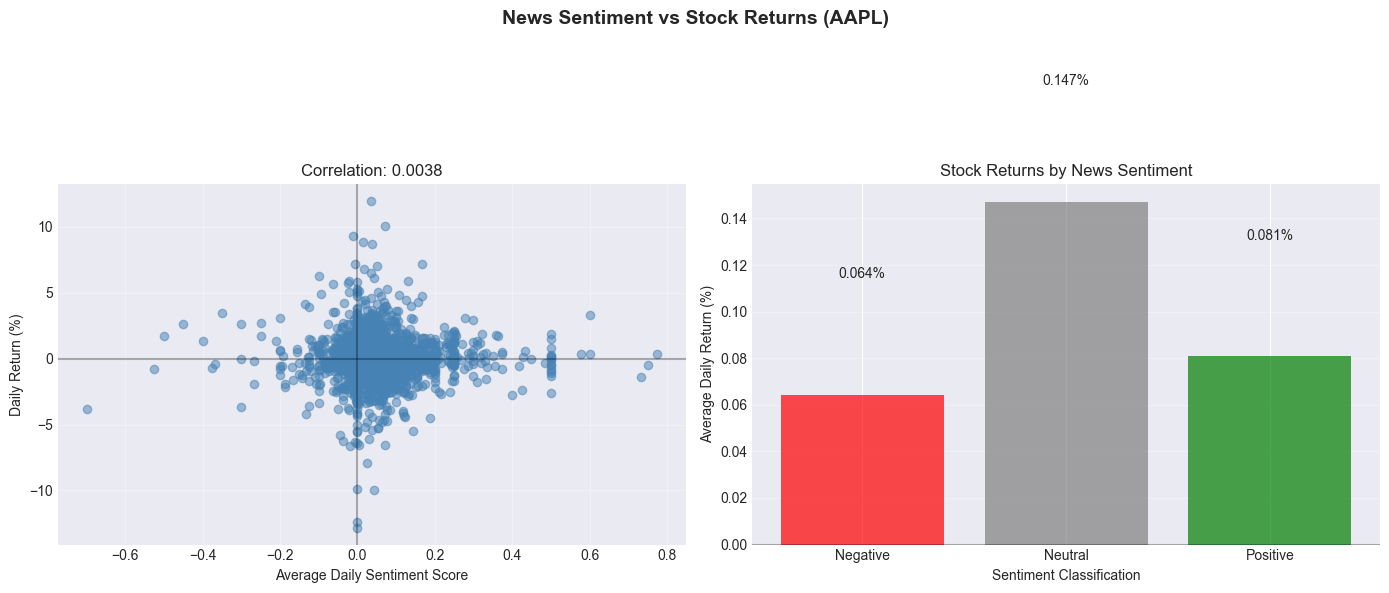

✅ Visualization saved to 'plots/sentiment_correlation.png'


In [25]:
# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('News Sentiment vs Stock Returns (AAPL)', fontsize=14, fontweight='bold')

# Scatter plot
axes[0].scatter(merged['avg_sentiment'], merged['daily_return'], alpha=0.5, color='steelblue')
axes[0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[0].axvline(x=0, color='black', linestyle='-', alpha=0.3)
axes[0].set_xlabel('Average Daily Sentiment Score')
axes[0].set_ylabel('Daily Return (%)')
axes[0].set_title(f'Correlation: {correlation:.4f}')
axes[0].grid(True, alpha=0.3)

# Bar chart
colors = ['green' if x == 'Positive' else 'red' if x == 'Negative' else 'gray' for x in returns_by_class.index]
bars = axes[1].bar(returns_by_class.index, returns_by_class.values, color=colors, alpha=0.7)
axes[1].set_xlabel('Sentiment Classification')
axes[1].set_ylabel('Average Daily Return (%)')
axes[1].set_title('Stock Returns by News Sentiment')
axes[1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, returns_by_class.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                 f'{val:.3f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../plots/sentiment_correlation.png', dpi=150)
plt.show()

print("✅ Visualization saved to 'plots/sentiment_correlation.png'")

In [26]:
print("\n" + "="*60)
print("TASK 3 COMPLETED SUCCESSFULLY!")
print("="*60)
print(f"\n📊 FINAL RESULTS:")
print(f"   • Correlation Coefficient: {correlation:.4f}")
print(f"   • Positive sentiment days: {len(merged[merged['sentiment_class'] == 'Positive'])}")
print(f"   • Negative sentiment days: {len(merged[merged['sentiment_class'] == 'Negative'])}")
print(f"   • Neutral sentiment days: {len(merged[merged['sentiment_class'] == 'Neutral'])}")

print("\n💡 INVESTMENT INSIGHT:")
print("   Based on the correlation analysis:")
if correlation > 0.15:
    print("   → Consider incorporating sentiment signals into trading strategy")
elif correlation < -0.15:
    print("   → Consider contrarian strategy (buy on negative news, sell on positive)")
else:
    print("   → News sentiment alone may not be sufficient for trading decisions")
    print("   → Consider combining with other factors or analyzing lagged effects")


TASK 3 COMPLETED SUCCESSFULLY!

📊 FINAL RESULTS:
   • Correlation Coefficient: 0.0038
   • Positive sentiment days: 779
   • Negative sentiment days: 132
   • Neutral sentiment days: 1209

💡 INVESTMENT INSIGHT:
   Based on the correlation analysis:
   → News sentiment alone may not be sufficient for trading decisions
   → Consider combining with other factors or analyzing lagged effects
